# 01 · Quickstart: a modal basis in five minutes

**Who this is for:** you have a deformable mirror (DM) and want a set of modes to control it with: KL, Zernike, Hadamard, or something similar. You don't want to read a textbook first.

**What you get:** a *modal-to-command matrix* (M2C), a NumPy array of shape `(n_actuators, n_modes)`. Column `k` holds the actuator commands that put mode `k` on the mirror. Every generator in `aobasis` returns one of these.

```
pip install aobasis            # the library
pip install "aobasis[plot]"    # + matplotlib, for the plots in these notebooks
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import aobasis

plt.rcParams["figure.dpi"] = 80
print("aobasis", aobasis.__version__)

aobasis 2.0.0


## 1. Describe your actuators

`aobasis` only needs the actuator coordinates: an `(n_actuators, 2)` array of `(x, y)`, in metres, centred on the pupil. The row order is your DM's actuator order, so row `i` of the M2C drives actuator `i`.

For a square-grid DM in a circular pupil there is a helper. Here, a 10 m pupil with 20 actuators across:

(276, 2)


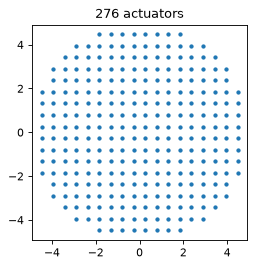

In [2]:
positions = aobasis.make_circular_actuator_grid(telescope_diameter=10.0, grid_size=20)
print(positions.shape)  # (n_actuators, 2)

plt.figure(figsize=(3.5, 3.5))
plt.scatter(*positions.T, s=8)
plt.gca().set_aspect("equal")
plt.title(f"{len(positions)} actuators")
plt.show()

If you already have a boolean map of your DM, `aobasis.positions_from_mask(mask, pitch)` turns it into positions in the usual row-major order. [04 · Actuator geometry](04_actuator_geometry.ipynb) covers hexagonal grids, central obstructions and spiders.

## 2. Generate modes

Choose a generator, give it the positions and any physical parameters, and call `generate(n_modes)`. KL modes are the usual choice for correcting atmospheric turbulence:

In [3]:
kl = aobasis.KLBasisGenerator(positions, fried_parameter=0.16, outer_scale=30.0)
m2c = kl.generate(n_modes=50, ignore_piston=True)
print(m2c.shape)

(276, 50)


`ignore_piston=True` keeps piston (a constant offset over the pupil) out of the basis. A wavefront sensor can't see piston, so you usually don't want to control it.

## 3. Look at them

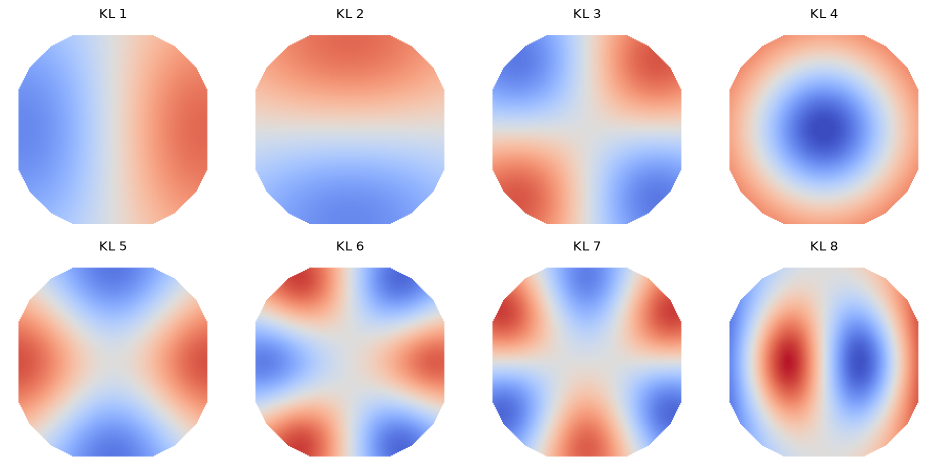

In [4]:
kl.plot(count=8, title_prefix="KL", interpolate=True)

## 4. Use them

To put a combination of modes on the DM, multiply the M2C by a vector of modal coefficients. To go back from commands to coefficients, use the least-squares inverse (the C2M):

In [5]:
coefficients = np.zeros(50)
coefficients[[0, 3]] = [1.0, -0.5]          # some of mode 0, a little of mode 3
commands = m2c @ coefficients                # (n_actuators,): send these to the DM

c2m = aobasis.command_to_mode_matrix(m2c)    # (n_modes, n_actuators)
print(np.round(c2m @ commands, 6)[:5])       # recovers the coefficients

[ 1.  -0.   0.  -0.5 -0. ]


## 5. Save them

`save` writes an `.npz` file with the modes, the positions and how they were made. `load` reads it back:

In [6]:
kl.save("quickstart_kl.npz")
loaded = aobasis.BasisGenerator.load("quickstart_kl.npz")
print(loaded.basis_type, loaded.modes.shape, loaded.parameters)

KLBasisGenerator (276, 50) {'fried_parameter': 0.16, 'outer_scale': 30.0, 'use_gpu': False, 'r0_wavelength': 5e-07, 'wavelength': 5e-07}


For other AO software, `save_fits` writes a FITS file (it needs `pip install "aobasis[fits]"`); see [08 · Saving and sharing](08_saving_and_sharing.ipynb).

## The same thing for other bases

Every generator follows the same pattern: constructor, `generate`, `plot`, `save`.

In [7]:
zernike = aobasis.ZernikeBasisGenerator(positions, pupil_radius=5.0).generate(30, ignore_piston=True)
hadamard = aobasis.HadamardBasisGenerator(positions).generate(len(positions))
zonal = aobasis.ZonalBasisGenerator(positions).generate(len(positions))
print(zernike.shape, hadamard.shape, zonal.shape)

(276, 30) (276, 276) (276, 276)


## Where next

| If you want to… | read |
|---|---|
| pick the right basis for your job | [02 · A tour of the bases](02_tour_of_bases.ipynb) |
| control piston, tip/tilt, normalization, orthogonality | [03 · Shaping a basis](03_shaping_a_basis.ipynb) |
| describe a hexagonal DM, an obscured pupil or spiders | [04 · Actuator geometry](04_actuator_geometry.ipynb) |
| understand KL modes and turbulence statistics | [05 · KL modes and turbulence](05_kl_and_turbulence.ipynb) |
| fit modes to real DM influence functions | [06 · Influence functions and DM KL](06_influence_functions.ipynb) |
| measure interaction matrices efficiently | [07 · Calibration patterns](07_calibration.ipynb) |
| exchange bases with other software | [08 · Saving and sharing](08_saving_and_sharing.ipynb) |

The scripts in [`examples/`](../examples) do common jobs end to end, for example `python examples/make_m2c.py kl --grid-size 20 --n-modes 50 -o m2c.fits`.

In [8]:
import os

os.remove("quickstart_kl.npz")  # tidy up